---
title: "CH4 absorption cross-section LUT"
---

# Building a single-gas absorption LUT — CH$_4$

This notebook exercises the end-to-end single-gas pipeline in `plume_simulation.hapi_lut`. We fetch HITRAN line parameters for methane, evaluate the Voigt-profile absorption cross-section $\sigma(\nu; T, p)$ on a coarse $(T, p)$ grid, and inspect how the cross-section changes with temperature and pressure. The physics is derived in [00_hapi_lut_derivation.md](00_hapi_lut_derivation.md); here we focus on the pipeline + visual sanity checks.

The LUT grid is intentionally small — 3 temperatures × 3 pressures over a 500-cm⁻¹ window at 0.05-cm⁻¹ spectral resolution. That's enough to recover the pressure-broadening signature and the Boltzmann redistribution of line strength with $T$ without the ~30 min runtime of an operational grid (7 × 6 × ~0.01 cm⁻¹).

**Dependencies:** `hitran-api` (HAPI), `xarray`, `matplotlib`. All covered by the `plume-simulation` pixi environment. HITRAN line parameters are fetched on first run and cached under `projects/plume_simulation/data/hitran_cache/` (git-ignored).

In [1]:
import logging
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")  # silence HAPI SyntaxWarnings on regex strings

import matplotlib.pyplot as plt
import numpy as np

from plume_simulation.hapi_lut import (
    ATMOSPHERIC_GASES,
    LUTGridConfig,
    build_lut_dataset,
    compute_absorption_lut,
    fetch_hitran_data,
)

logging.basicConfig(level=logging.WARNING, format="%(message)s")

# All paths resolve relative to the research_notebook repo root.
REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "pixi.toml").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
DATA_ROOT = REPO_ROOT / "projects" / "plume_simulation" / "data"
CACHE_DIR = DATA_ROOT / "hitran_cache"
LUT_DIR = DATA_ROOT / "hapi_lut"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
LUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Cache dir: {CACHE_DIR}")
print(f"LUT out:   {LUT_DIR}")

Cache dir: /home/azureuser/localfiles/research_notebook/projects/plume_simulation/data/hitran_cache
LUT out:   /home/azureuser/localfiles/research_notebook/projects/plume_simulation/data/hapi_lut


## 1. Gas and grid configuration

`ATMOSPHERIC_GASES` carries a curated registry of the SWIR/NIR species most relevant to methane / CO$_2$ remote sensing. We pull the CH$_4$ entry and **narrow the spectral window** to the 4000–4500 cm⁻¹ fundamental $\nu_3$ stretch — broad enough to see the rotational envelope, narrow enough to keep the LUT at ~10⁵ cells.

The default `LUTGridConfig` covers 200–320 K and 0.1–1.0 atm; for this tutorial we use coarse 3×3 knots so the HAPI calls take under two minutes on a laptop.

In [2]:
ch4 = ATMOSPHERIC_GASES["CH4"]
# Narrow the window — the full registry entry spans 4000-8000 cm^-1 (SWIR +
# NIR). 4000-4500 cm^-1 covers CH4's strongest SWIR absorption and keeps the
# HAPI download small (~1 MB of line parameters).
ch4_window = type(ch4)(
    name=ch4.name,
    molecule_id=ch4.molecule_id,
    isotopologue_id=ch4.isotopologue_id,
    nu_min=4000.0,
    nu_max=4500.0,
    description=ch4.description,
)
print(ch4_window)

grid = LUTGridConfig(
    T_grid=np.array([220.0, 260.0, 300.0]),  # upper tropo / mid tropo / surface
    P_grid=np.array([0.3, 0.6, 1.0]),        # tropopause / free tropo / surface
    nu_step=0.05,                             # 10 000 spectral points
)
print(f"grid: T={grid.T_grid.tolist()} K, P={grid.P_grid.tolist()} atm")
print(f"expected σ LUT shape: ({int((ch4_window.nu_max-ch4_window.nu_min)/grid.nu_step)}, {len(grid.T_grid)}, {len(grid.P_grid)})")

GasConfig(CH4, M6, I1)
grid: T=[220.0, 260.0, 300.0] K, P=[0.3, 0.6, 1.0] atm
expected σ LUT shape: (10000, 3, 3)


## 2. Fetch HITRAN line parameters

On first run this downloads the line list from `hitran.org` and caches two files (`CH4.data`, `CH4.header`) under `CACHE_DIR`. Subsequent runs reuse the cache.

In [3]:
fetch_hitran_data(ch4_window, cache_dir=CACHE_DIR)

HAPI version: 1.3.0.0
To get the most up-to-date version please check http://hitran.org/hapi
ATTENTION: Python versions of partition sums from TIPS-2021 are now available in HAPI code

           MIT license: Copyright 2021 HITRAN team, see more at http://hitran.org. 

           If you use HAPI in your research or software development,
           please cite it using the following reference:
           R.V. Kochanov, I.E. Gordon, L.S. Rothman, P. Wcislo, C. Hill, J.S. Wilzewski,
           HITRAN Application Programming Interface (HAPI): A comprehensive approach
           to working with spectroscopic data, J. Quant. Spectrosc. Radiat. Transfer 177, 15-30 (2016)
           DOI: 10.1016/j.jqsrt.2016.03.005

           ATTENTION: This is the core version of the HITRAN Application Programming Interface.
                      For more efficient implementation of the absorption coefficient routine, 
                      as well as for new profiles, parameters and other functional,
      

BEGIN DOWNLOAD: CH4
  65536 bytes written to /home/azureuser/localfiles/research_notebook/projects/plume_simulation/data/hitran_cache/CH4.data
  65536 bytes written to /home/azureuser/localfiles/research_notebook/projects/plume_simulation/data/hitran_cache/CH4.data
  65536 bytes written to /home/azureuser/localfiles/research_notebook/projects/plume_simulation/data/hitran_cache/CH4.data
  65536 bytes written to /home/azureuser/localfiles/research_notebook/projects/plume_simulation/data/hitran_cache/CH4.data
  65536 bytes written to /home/azureuser/localfiles/research_notebook/projects/plume_simulation/data/hitran_cache/CH4.data
  65536 bytes written to /home/azureuser/localfiles/research_notebook/projects/plume_simulation/data/hitran_cache/CH4.data
  65536 bytes written to /home/azureuser/localfiles/research_notebook/projects/plume_simulation/data/hitran_cache/CH4.data
  65536 bytes written to /home/azureuser/localfiles/research_notebook/projects/plume_simulation/data/hitran_cache/CH4.d

                     Lines parsed: 39817
PROCESSED


PosixPath('/home/azureuser/localfiles/research_notebook/projects/plume_simulation/data/hitran_cache')

## 3. Compute $\sigma(\nu; T, p)$ on the LUT grid

For each $(T, p)$ knot HAPI performs the line-by-line Voigt sum (§2 of the derivation note) and returns a cross-section array of shape `(n_nu,)`. Runtime is dominated by the convolution inside HAPI — typically a few seconds per knot on a warm cache, so our 3 × 3 grid is a ~1-minute job.

In [4]:
nu, sigma, wl_nm = compute_absorption_lut(
    ch4_window, grid, cache_dir=CACHE_DIR, progress=False,
)
print(f"σ LUT shape: {sigma.shape}  [n_nu, n_T, n_P]")
print(f"σ range: [{sigma.min():.2e}, {sigma.max():.2e}] cm²/molecule")
print(f"ν range: [{nu.min():.1f}, {nu.max():.1f}] cm⁻¹ = [{wl_nm[-1]:.1f}, {wl_nm[0]:.1f}] nm")

Using /home/azureuser/localfiles/research_notebook/projects/plume_simulation/data/hitran_cache

CH4


                     Lines parsed: 39817


{'air': 0.999998, 'self': 2e-06}


25.030944 seconds elapsed for abscoef; nlines = 39817


{'air': 0.999998, 'self': 2e-06}


...

24.904526 seconds elapsed for abscoef; nlines = 39817


{'air': 0.999998, 'self': 2e-06}


25.088933 seconds elapsed for abscoef; nlines = 39817


{'air': 0.999998, 'self': 2e-06}


25.745720 seconds elapsed for abscoef; nlines = 39817
σ LUT shape: (10000, 3, 3)  [n_nu, n_T, n_P]
σ range: [4.41e-25, 1.03e-19] cm²/molecule
ν range: [4000.0, 4500.0] cm⁻¹ = [2222.2, 2500.0] nm


Wrap in the CF-conformant `xarray.Dataset`:

In [5]:
ds = build_lut_dataset(ch4_window, grid, nu, sigma, wl_nm)
ds

<xarray.Dataset> Size: 880kB
Dimensions:                   (wavenumber: 10000, temperature: 3, pressure: 3)
Coordinates:
  * wavenumber                (wavenumber) float64 80kB 4e+03 4e+03 ... 4.5e+03
    wavelength                (wavenumber) float64 80kB 2.5e+03 ... 2.222e+03
  * temperature               (temperature) float64 24B 220.0 260.0 300.0
  * pressure                  (pressure) float64 24B 0.3 0.6 1.0
Data variables:
    absorption_cross_section  (wavenumber, temperature, pressure) float64 720kB ...
Attributes: (12/14)
    title:                CH4 Absorption Cross-Section Look-Up Table
    institution:          Generated using HITRAN API (HAPI)
    source:               HITRAN molecular spectroscopic database
    molecule:             CH4
    molecule_id:          6
    isotopologue_id:      1
    ...                   ...
    temperature_range_K:  220-300
    pressure_range_atm:   0.30-1.00
    line_shape:           Voigt profile
    description:          Methane — primary greenhouse-gas retrieval target.
    conventions:          CF-1.8
    creation_date:        2026-04-23T10:55:46.120389+00:00

## 4. Visual sanity checks

### 4a. Cross-section at one reference state

At $T = 260$ K, $p = 0.6$ atm (a mid-troposphere state) the methane $\nu_3$ band structure is clearly visible — a forest of sharp Voigt lines between $\sim 4150$ and $\sim 4450$ cm⁻¹ (2250–2410 nm).

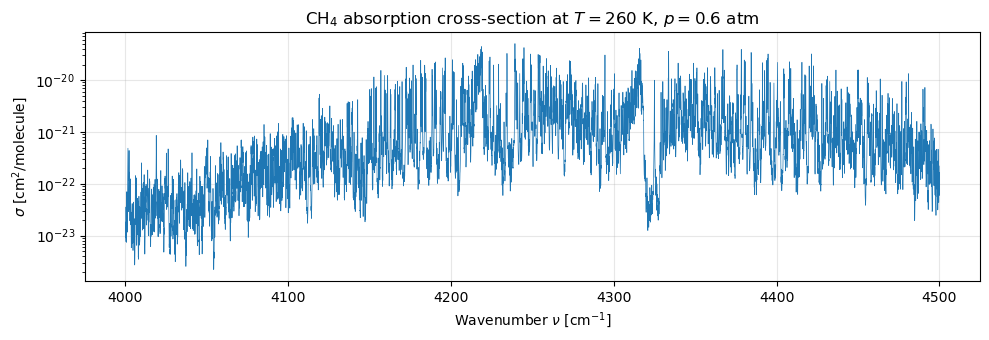

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(10, 3.5))
sigma_ref = ds["absorption_cross_section"].sel(temperature=260.0, pressure=0.6)
ax.plot(ds["wavenumber"], sigma_ref, lw=0.5, color="C0")
ax.set_yscale("log")
ax.set_xlabel(r"Wavenumber $\nu$ [cm$^{-1}$]")
ax.set_ylabel(r"$\sigma$ [cm$^2$/molecule]")
ax.set_title(r"CH$_4$ absorption cross-section at $T=260$ K, $p=0.6$ atm")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 4b. Temperature dependence at fixed pressure

The Boltzmann factor in $S_i(T)$ rearranges line strength between low-$E''$ and high-$E''$ transitions as $T$ changes. At higher $T$ the thermal population of excited rovibrational levels rises, so lines from those levels gain strength. We visualise this with a zoom into a single Q-branch feature.

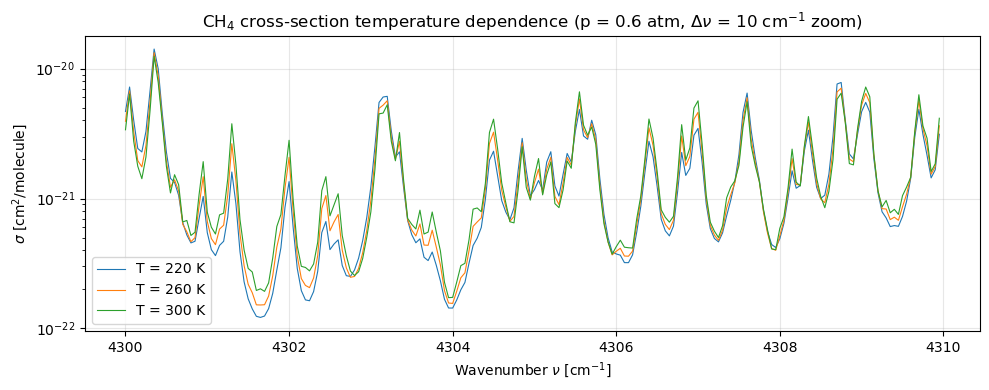

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
zoom_mask = (ds["wavenumber"] > 4300) & (ds["wavenumber"] < 4310)
for T in grid.T_grid:
    sigma_T = ds["absorption_cross_section"].sel(temperature=T, pressure=0.6)
    ax.plot(ds["wavenumber"][zoom_mask], sigma_T[zoom_mask], lw=0.8, label=f"T = {T:.0f} K")
ax.set_yscale("log")
ax.set_xlabel(r"Wavenumber $\nu$ [cm$^{-1}$]")
ax.set_ylabel(r"$\sigma$ [cm$^2$/molecule]")
ax.set_title(r"CH$_4$ cross-section temperature dependence (p = 0.6 atm, $\Delta\nu$ = 10 cm$^{-1}$ zoom)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 4c. Pressure dependence at fixed temperature

Pressure broadening widens the Lorentzian half-width $\gamma_L \propto p$, which lowers peak amplitude and raises the absorption *between* lines (line wings overlap more). The same 10-cm⁻¹ zoom makes the effect obvious.

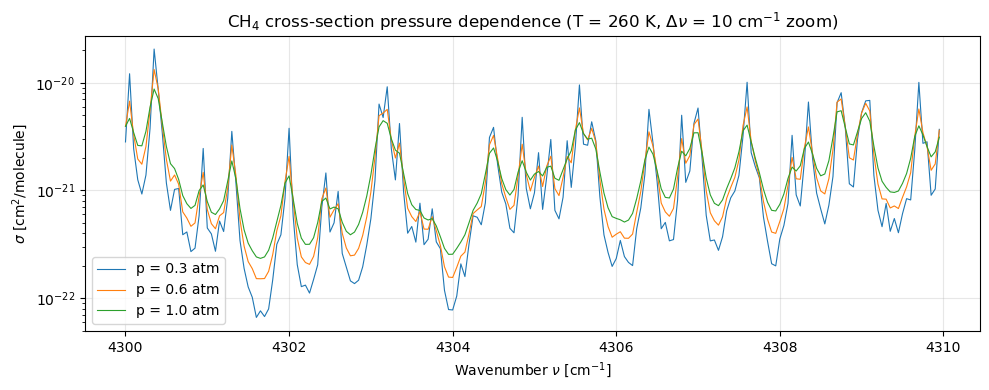

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
for p in grid.P_grid:
    sigma_p = ds["absorption_cross_section"].sel(temperature=260.0, pressure=p)
    ax.plot(ds["wavenumber"][zoom_mask], sigma_p[zoom_mask], lw=0.8, label=f"p = {p:.1f} atm")
ax.set_yscale("log")
ax.set_xlabel(r"Wavenumber $\nu$ [cm$^{-1}$]")
ax.set_ylabel(r"$\sigma$ [cm$^2$/molecule]")
ax.set_title(r"CH$_4$ cross-section pressure dependence (T = 260 K, $\Delta\nu$ = 10 cm$^{-1}$ zoom)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Reading the plot.** Going from 0.3 atm (blue) to 1.0 atm (green):
- Peak cross-sections drop by roughly 2–3× (Lorentzian area-preserving broadening).
- Valleys between lines rise, sometimes by more than 10× — the "line-wing blending" that makes high-pressure cross-sections look smoother.
- The shift in peak position is sub-bin (we'd need $\Delta\nu \ll 0.05$ cm⁻¹ to resolve pressure-induced line shifts).

## 5. Save the LUT

The generated NetCDF is git-ignored by design — each user regenerates it locally. Downstream notebooks expect it at the canonical path below.

In [9]:
out_path = LUT_DIR / "ch4_absorption_lut.nc"
ds.to_netcdf(
    out_path,
    encoding={
        "absorption_cross_section": {"zlib": True, "complevel": 4, "dtype": "float32"}
    },
)
print(f"wrote {out_path}  ({out_path.stat().st_size/1e6:.2f} MB)")

wrote /home/azureuser/localfiles/research_notebook/projects/plume_simulation/data/hapi_lut/ch4_absorption_lut.nc  (0.47 MB)


## 6. Summary

- HAPI's `absorptionCoefficient_Voigt` gives us the line-by-line cross-section per molecule at any $(T, p)$ — we stitched 9 such calls into a 3D `xarray.Dataset`.
- The cross-section dependence on $T$ (Boltzmann redistribution) and $p$ (pressure broadening) is directly observable in a 10-cm⁻¹ zoom of the CH$_4$ $\nu_3$ band.
- This LUT is the offline artefact for every downstream Beer–Lambert forward model — see [02_hapi_lut_multigas.ipynb](02_hapi_lut_multigas.ipynb) for multi-gas LUTs and [03_beers_law_with_lut.ipynb](03_beers_law_with_lut.ipynb) for the plume-enhancement retrieval.